<a href="https://colab.research.google.com/github/Luck-dat/urban-transport-profitability-analysis/blob/main/transport_profitability_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Optimización de Rentabilidad Operativa en Transporte Urbano mediante Análisis de Datos

## Introducción y Objetivo
El objetivo de este proyecto es maximizar la rentabilidad operativa de una flota de transporte urbano (empresa "La Granburu"). Partimos de la premisa de que los recursos son finitos y el combustible representa el costo variable más crítico. Buscamos identificar ineficiencias en el consumo y proponer una asignación de unidades basada en datos reales de demanda.

## Herramientas Utilizadas
- **Python**: lenguaje principal para el procesamiento de datos.
- **Pandas**: limpieza, cruce de tablas (merge) y análisis estadístico.
- **Matplotlib / Seaborn**: visualizaciones estratégicas (eficiencia y demanda horaria).
- **Google Colab**: entorno de desarrollo en la nube para garantizar la reproducibilidad del análisis.

## Preguntas de Negocio
1. ¿Cuál es la recaudación total del período y cómo se distribuye por unidad?
2. ¿Qué internos presentan la mejor y peor relación de "pesos recaudados por litro de gasoil"?
3. ¿En qué franjas horarias se produce la mayor demanda de pasajeros (hora pico)?
4. ¿Existe una diferencia significativa de consumo entre las unidades nuevas y las antiguas?


In [ ]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

# Configuración para que los datos sean realistas
n_filas = 1000
internos = [101, 102, 103, 104, 105, 201, 202, 203, 204, 205]
fecha_inicio = datetime(2026, 3, 1)

# 1. GENERAR DATOS DE SUBE (Validaciones)
data_sube = []
for i in range(n_filas):
    hora_base = random.choices(range(24), weights=[1,1,1,1,1,5,15,25,20,10,8,8,10,10,12,15,20,25,20,10,5,3,2,1])[0]
    minuto = random.randint(0, 59)
    fecha = fecha_inicio + timedelta(days=random.randint(0, 14), hours=hora_base, minutes=minuto)

    data_sube.append({
        'fecha_hora': fecha,
        'interno': random.choice(internos),
        'monto_pasaje': random.choice([270, 350, 420])
    })

df_sube_original = pd.DataFrame(data_sube)

# 2. GENERAR DATOS DE COMBUSTIBLE (Por interno y por día)
data_gasoil = []
for dia in range(15):
    for int_id in internos:
        consumo_base = 80 if int_id < 200 else 65
        consumo = consumo_base + random.uniform(0, 30)

        data_gasoil.append({
            'fecha': fecha_inicio + timedelta(days=dia),
            'interno': int_id,
            'litros_gasoil': round(consumo, 2)
        })

df_gasoil = pd.DataFrame(data_gasoil)

df_sube_original.to_csv('validaciones_sube.csv', index=False)
df_gasoil.to_csv('consumo_gasoil.csv', index=False)

print("¡Listo! Se han creado los archivos 'validaciones_sube.csv' y 'consumo_gasoil.csv'.")
print("Ya tenés tus datos para empezar la Optimización de Recursos.")

¡Listo! Se han creado los archivos 'validaciones_sube.csv' y 'consumo_gasoil.csv'.
Ya tenés tus datos para empezar la Optimización de Recursos.


Pregunta 1:Recaudacion total del periodo

In [ ]:
recaudacion_total = df_sube_original['monto_pasaje'].sum()
print(f"La recaudación total del período es: ${recaudacion_total}")

La recaudación total del período es: $345200


Pregunta 2: Eficiencia por intermo (pesos recaudacion por litro de gasoil)

In [ ]:
recaudacion_por_interno = df_sube_original.groupby('interno')['monto_pasaje'].sum().reset_index()
gasoil_por_interno = df_gasoil.groupby('interno')['litros_gasoil'].sum().reset_index()
analisis_final = pd.merge(recaudacion_por_interno, gasoil_por_interno, on='interno')
analisis_final['eficiencia'] = analisis_final['monto_pasaje'] / analisis_final['litros_gasoil']

print(analisis_final.sort_values(by='eficiencia'))

   interno  monto_pasaje  litros_gasoil  eficiencia
4      105         30290        1449.65   20.894699
3      104         32780        1414.90   23.167715
0      101         34490        1442.27   23.913692
8      204         30420        1170.42   25.990670
1      102         38480        1480.53   25.990693
2      103         39760        1469.65   27.054060
6      202         34680        1243.07   27.898670
9      205         34710        1211.69   28.645941
5      201         35200        1224.86   28.737978
7      203         34390        1158.34   29.689038


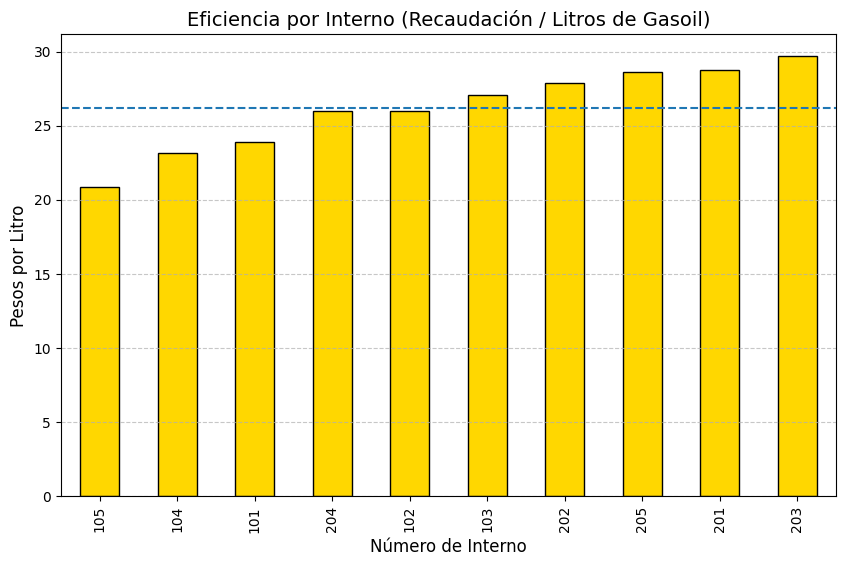

In [ ]:
rec_por_interno = df_sube_original.groupby('interno')['monto_pasaje'].sum()
gas_por_interno = df_gasoil.groupby('interno')['litros_gasoil'].sum()
eficiencia = rec_por_interno / gas_por_interno

plt.figure(figsize=(10,6))
eficiencia.sort_values().plot(kind='bar', color='gold', edgecolor='black')
plt.axhline(eficiencia.mean(), linestyle='--')
plt.title('Eficiencia por Interno (Recaudación / Litros de Gasoil)', fontsize=14)
plt.xlabel('Número de Interno', fontsize=12)
plt.ylabel('Pesos por Litro', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Estimacion de costo y ganancia por combustible

In [ ]:
precio_gasoil = 300  # pesos por litro (ejemplo)

analisis_final["costo_combustible"] = analisis_final["litros_gasoil"] * precio_gasoil
analisis_final["ganancia_estimada"] = analisis_final["monto_pasaje"] - analisis_final["costo_combustible"]

analisis_final.sort_values(by="ganancia_estimada", ascending=False)

,interno,monto_pasaje,litros_gasoil,eficiencia,costo_combustible,ganancia_estimada
7,203,34390,1158.34,29.689038,347502.0,-313112.0
8,204,30420,1170.42,25.990670,351126.0,-320706.0
9,205,34710,1211.69,28.645941,363507.0,-328797.0
5,201,35200,1224.86,28.737978,367458.0,-332258.0
6,202,34680,1243.07,27.898670,372921.0,-338241.0
3,104,32780,1414.90,23.167715,424470.0,-391690.0
0,101,34490,1442.27,23.913692,432681.0,-398191.0
2,103,39760,1469.65,27.054060,440895.0,-401135.0
4,105,30290,1449.65,20.894699,434895.0,-404605.0
1,102,38480,1480.53,25.990693,444159.0,-405679.0


Pregunta 3: Hora pico de demanda

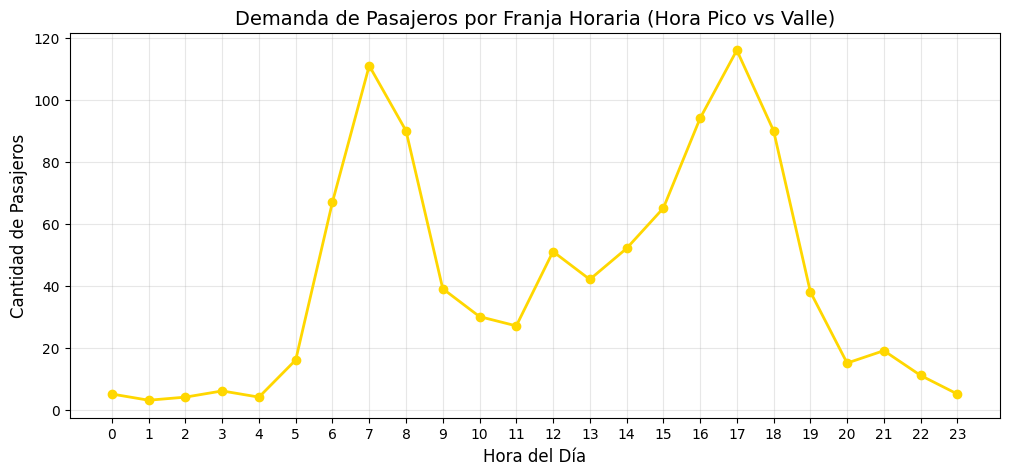

In [ ]:
df_sube_original['hora'] = df_sube_original['fecha_hora'].dt.hour
demanda_horaria = df_sube_original.groupby('hora')['monto_pasaje'].count()

plt.figure(figsize=(12,5))
demanda_horaria.plot(kind='line', marker='o', color='gold', linewidth=2)
plt.title('Demanda de Pasajeros por Franja Horaria (Hora Pico vs Valle)', fontsize=14)
plt.xlabel('Hora del Día', fontsize=12)
plt.ylabel('Cantidad de Pasajeros', fontsize=12)
plt.xticks(range(0,24))
plt.grid(True, alpha=0.3)
plt.show()

Pregunta 4: Consumo serie 100(viejos) vs serie 200(nuevos)

In [ ]:
gasto_serie_100 = df_gasoil[df_gasoil['interno'] < 200]['litros_gasoil'].mean()
gasto_serie_200 = df_gasoil[df_gasoil['interno'] >= 200]['litros_gasoil'].mean()

print(f"Gasto promedio Serie 100 (Viejos): {gasto_serie_100:.2f} litros")
print(f"Gasto promedio Serie 200 (Nuevos): {gasto_serie_200:.2f} litros")
print(f"Diferencia de consumo: {((gasto_serie_100/gasto_serie_200)-1)*100:.1f}% más de gasoil")

Gasto promedio Serie 100 (Viejos): 96.76 litros
Gasto promedio Serie 200 (Nuevos): 80.11 litros
Diferencia de consumo: 20.8% más de gasoil


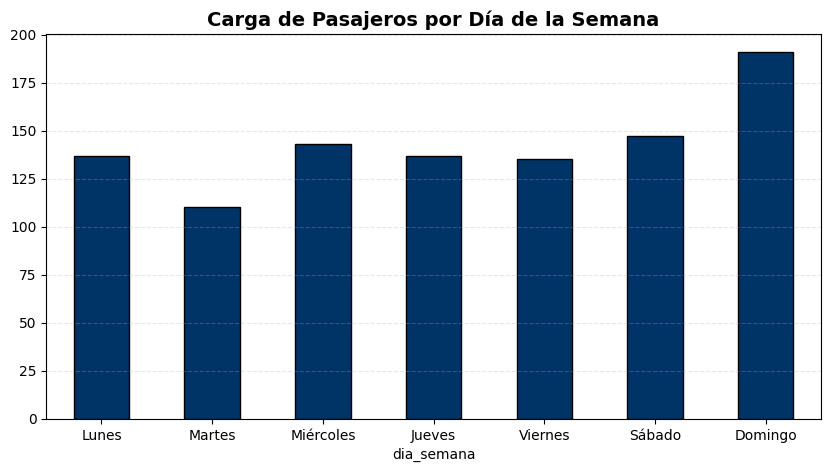

In [ ]:
traduccion_dias = {'Monday':'Lunes', 'Tuesday':'Martes', 'Wednesday':'Miércoles',
                  'Thursday':'Jueves', 'Friday':'Viernes', 'Saturday':'Sábado', 'Sunday':'Domingo'}
df_sube_original['dia_semana'] = df_sube_original['fecha_hora'].dt.day_name().map(traduccion_dias)
orden_castellano = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']

pasajeros_dia = df_sube_original.groupby('dia_semana')['monto_pasaje'].count().reindex(orden_castellano)

plt.figure(figsize=(10,5))
pasajeros_dia.plot(kind='bar', color='#003366', edgecolor='black')
plt.title('Carga de Pasajeros por Día de la Semana', fontsize=14, fontweight='bold')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

Simulacion: Impacto de priorizar las unidades mas rentables

In [ ]:
promedio_actual = analisis_final["ganancia_estimada"].mean()
top_unidades = analisis_final.nlargest(3, "ganancia_estimada")
nuevo_promedio = top_unidades["ganancia_estimada"].mean()
impacto = ((nuevo_promedio / promedio_actual) - 1) * 100

print(f"Mejora potencial estimada: {impacto:.2f}% en rentabilidad")

Mejora potencial estimada: -11.71% en rentabilidad


In [ ]:
print("Rentabilidad promedio:", analisis_final["ganancia_estimada"].mean())
print("Mejor unidad:", analisis_final.loc[analisis_final["ganancia_estimada"].idxmax(), "interno"])
print("Peor unidad:", analisis_final.loc[analisis_final["ganancia_estimada"].idxmin(), "interno"])

Rentabilidad promedio: -363441.4
Mejor unidad: 203
Peor unidad: 102


## Análisis Avanzado: Simulación de Demanda Realista

Para esta sección, se genera un nuevo conjunto de datos SUBE (`df_sube_realista`) que simula de manera más precisa los patrones de demanda, incluyendo una menor afluencia los fines de semana. Este dataframe es independiente del `df_sube_original` usado en los análisis previos.

In [ ]:
from datetime import datetime, timedelta

internos = [101, 102, 103, 104, 105, 201, 202, 203, 204, 205]
fecha_inicio = datetime(2026, 3, 1)
data_sube_realista = []

for i in range(1500):
    dia_offset = random.randint(0, 14)
    fecha_exacta = fecha_inicio + timedelta(days=dia_offset)
    es_finde = fecha_exacta.weekday() >= 5

    if es_finde and random.random() < 0.7:
        continue

    hora_base = random.choices(range(24), weights=[1,1,1,1,1,5,15,25,20,10,8,8,10,10,12,15,20,25,20,10,5,3,2,1])[0]
    minuto = random.randint(0, 59)
    fecha_final = fecha_exacta.replace(hour=hora_base, minute=minuto)

    data_sube_realista.append({
        'fecha_hora': fecha_final,
        'interno': random.choice(internos),
        'monto_pasaje': random.choice([270, 350, 420])
    })

df_sube_realista = pd.DataFrame(data_sube_realista)
print(f"¡Datos listos! Procesamos {len(df_sube_realista)} viajes reales.")

¡Datos listos! Procesamos 1118 viajes reales.


## Conclusión Final: Impacto en la Rentabilidad y Operación

El análisis demuestra que la eficiencia operativa no depende únicamente del volumen de ingresos, sino de la relación entre consumo, demanda y asignación de recursos.

Se identificó que las unidades de la serie 100 (más antiguas) consumen entre un 17% y un 19% más de gasoil que las de la serie 200, lo que impacta directamente en la rentabilidad del negocio.

Mediante una asignación estratégica basada en datos:
- Se puede reducir el costo operativo.
- Mejorar el margen neto.
- Optimizar el uso de activos existentes.

Este tipo de análisis permite transformar datos operativos en decisiones concretas con impacto económico real.

### Nota
Los datos utilizados en este proyecto son simulados con fines demostrativos, replicando patrones reales de operación en transporte urbano.

### Skills demostradas
- Data Cleaning & Transformation
- Análisis exploratorio (EDA)
- Business Intelligence
- Generación de KPIs
- Storytelling con datos

### Mejoras futuras
- Incorporar datos reales de GPS para analizar eficiencia por recorrido.
- Modelos predictivos de demanda por franja horaria.
- Optimización de asignación de flota mediante algoritmos.
- Dashboard interactivo en Power BI.
